In [19]:
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
ds_legacy = xr.open_zarr("/Users/elynnw/Downloads/fme_legacy_output/processed.zarr")
ds = xr.open_dataset("/Users/elynnw/Downloads/fme_output/SMS_P512.ne30pg2_r05_IcoswISC30E3r5.WCYCL1850NS.pm-cpu_gnu.allactive-fme_output.20260414_194815_f6occt.eam.h0.0001-01-01-00000.nc")

In [3]:
ds_legacy

<xarray.Dataset> Size: 147MB
Dimensions:                                        (lat: 180, lon: 360,
                                                    time: 4, lev: 80, nbnd: 2,
                                                    P3_input_dim: 16,
                                                    P3_output_dim: 32)
Coordinates:
  * lat                                            (lat) float64 1kB -89.24 ....
  * lon                                            (lon) float64 3kB 0.5 ... ...
  * time                                           (time) object 32B 0001-01-...
  * P3_input_dim                                   (P3_input_dim) int32 64B 1...
  * P3_output_dim                                  (P3_output_dim) int32 128B ...
Dimensions without coordinates: lev, nbnd
Data variables: (12/103)
    ak_0                                           float32 4B ...
    ak_1                                           float32 4B ...
    ak_2                                           float32 4B ...
    ak_3                                           float32 4B ...
    ak_4                                           float32 4B ...
    ak_5                                           float32 4B ...
    ...                                             ...
    V_2                                            (time, lat, lon) float32 1MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    V_3                                            (time, lat, lon) float32 1MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    V_4                                            (time, lat, lon) float32 1MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    V_5                                            (time, lat, lon) float32 1MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    V_6                                            (time, lat, lon) float32 1MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    V_7                                            (time, lat, lon) float32 1MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    units:                m2/s2
    long_name:            Surface geopotential
    cell_methods:         time: point
    cell_measures:        area: area
    history:              Dataset computed by full-model/scripts/e3smv2_data_...
    vertical_coordinate:  The pressure at level interfaces can by computed as...

In [9]:
diff = {}
for var in ds.data_vars:
    if var in ds_legacy.data_vars:
        try:
            diff[var] = ds[var] - ds_legacy[var]
        except:
            pass

In [10]:
diff.keys()

dict_keys(['hyam', 'hybm', 'P0', 'datesec', 'ndbase', 'nsbase', 'nbdate', 'nbsec', 'ndcur', 'nscur', 'co2vmr', 'ch4vmr', 'n2ovmr', 'f11vmr', 'f12vmr', 'sol_tsi', 'nsteph', 'FLDS', 'FLNT', 'FLUS', 'FLUT', 'FSDS', 'FSUS', 'FSUTOA', 'ICEFRAC', 'LANDFRAC', 'LHFLX', 'OCNFRAC', 'PS', 'SHFLX', 'SOLIN', 'TAUX', 'TAUY', 'TS', 'T_0', 'T_1', 'T_2', 'T_3', 'T_4', 'T_5', 'T_6', 'T_7', 'U_0', 'U_1', 'U_2', 'U_3', 'U_4', 'U_5', 'U_6', 'U_7', 'V_0', 'V_1', 'V_2', 'V_3', 'V_4', 'V_5', 'V_6', 'V_7'])

In [18]:
diff["SOLIN"].dims


('time', 'lat', 'lon')

/var/folders/7c/m08mqdls11j344m3jmpw599w0000gp/T/ipykernel_95817/3572862135.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


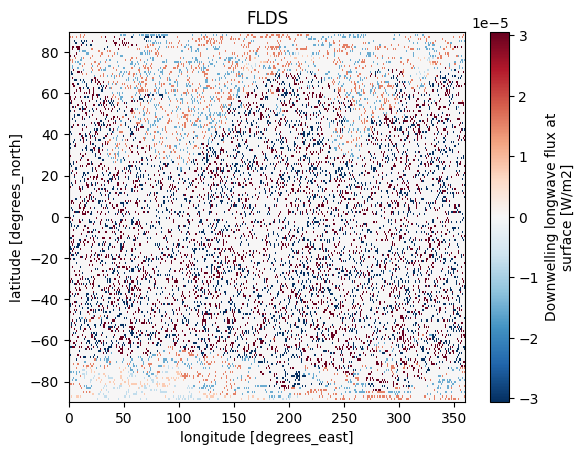

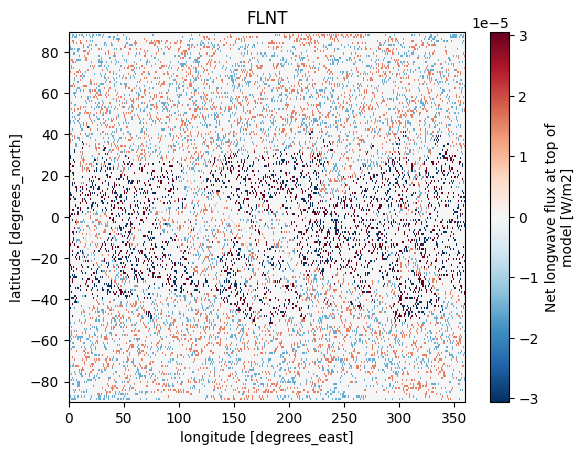

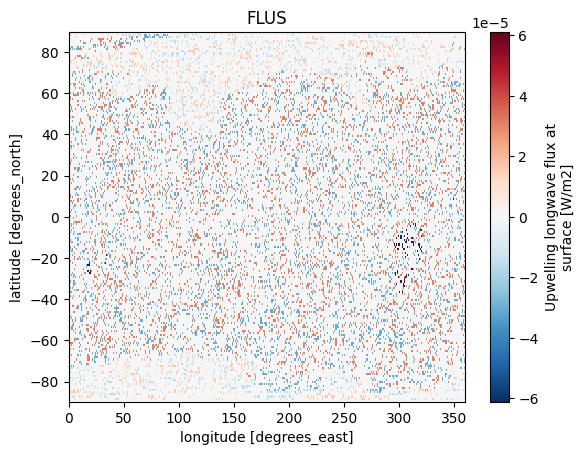

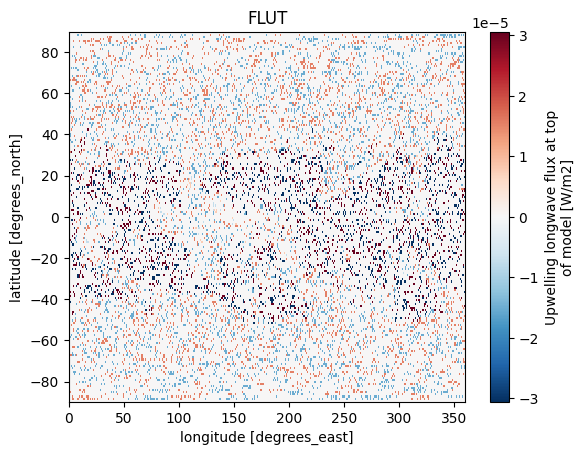

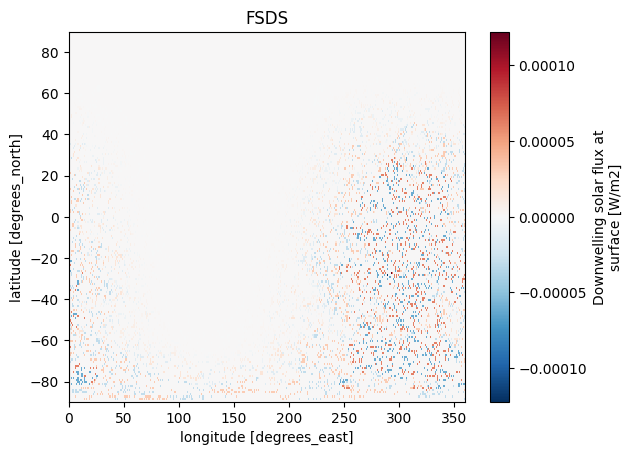

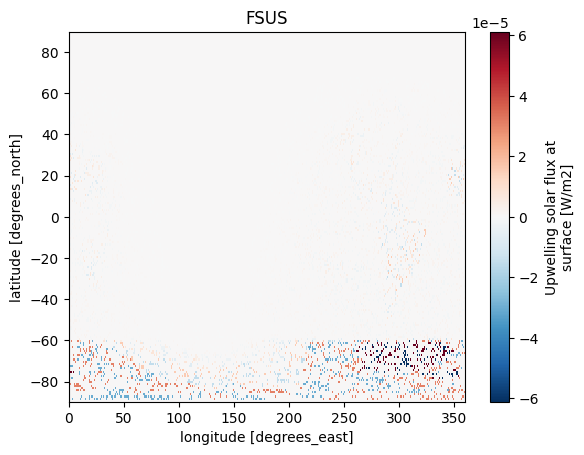

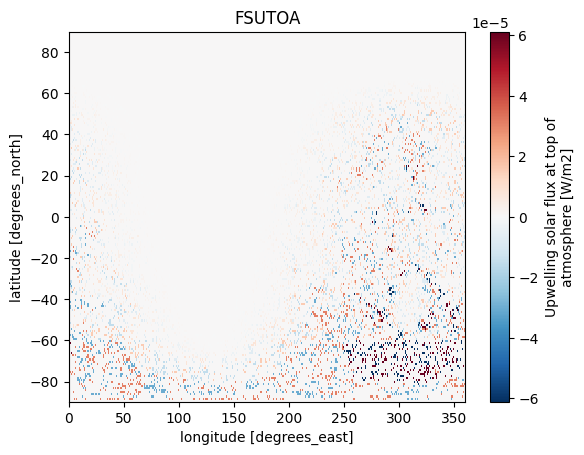

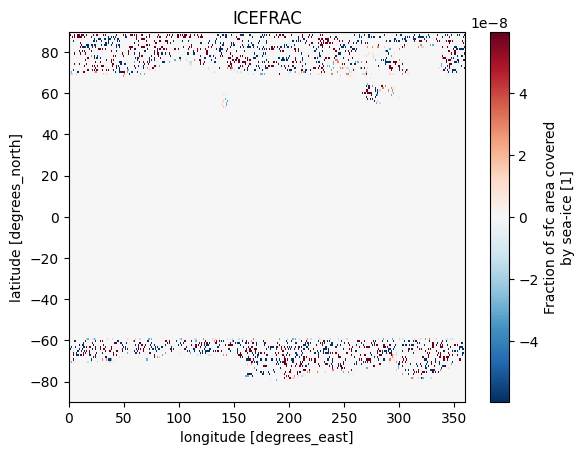

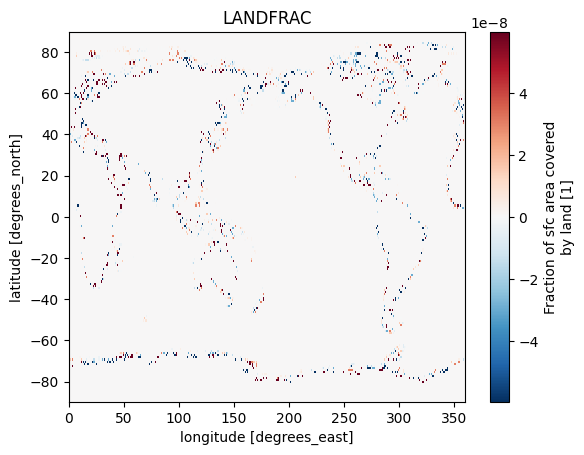

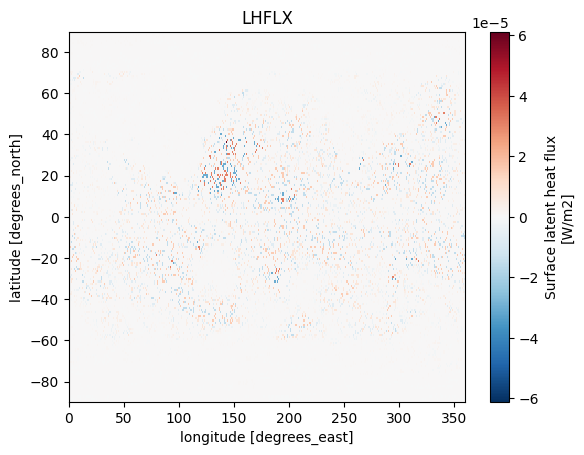

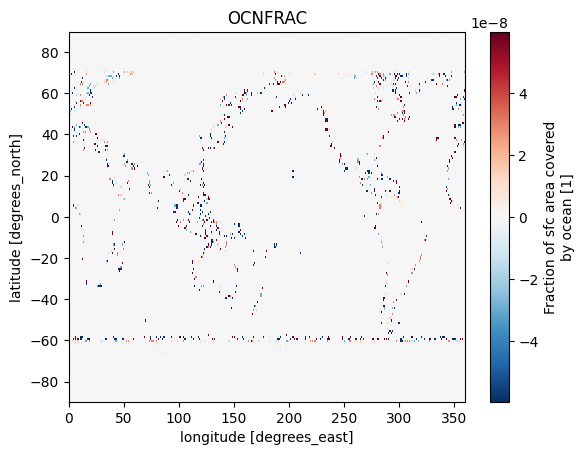

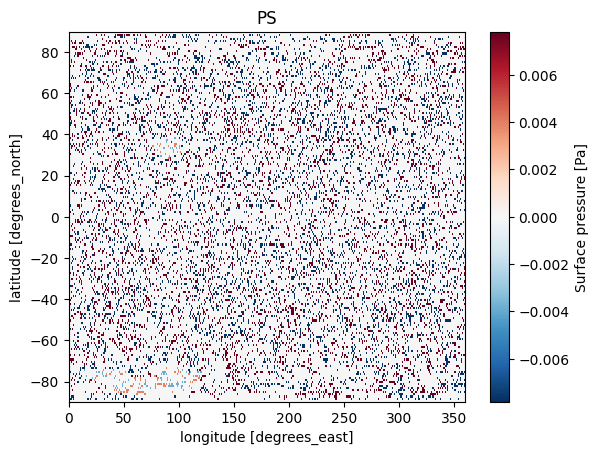

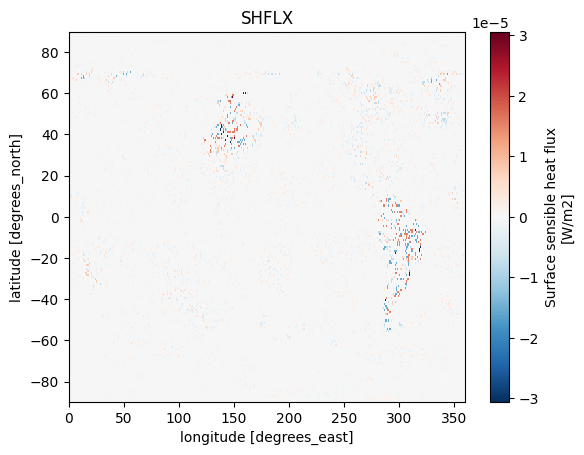

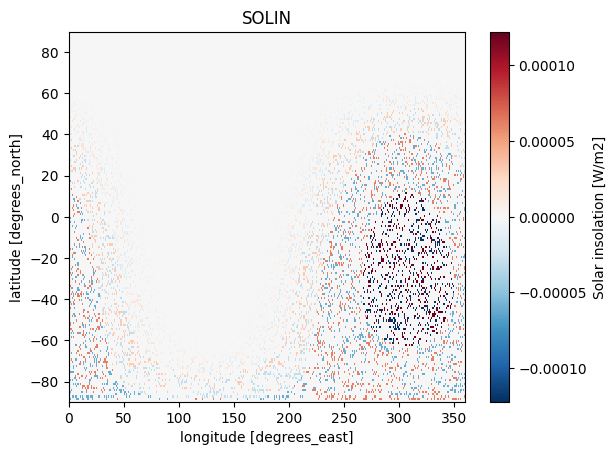

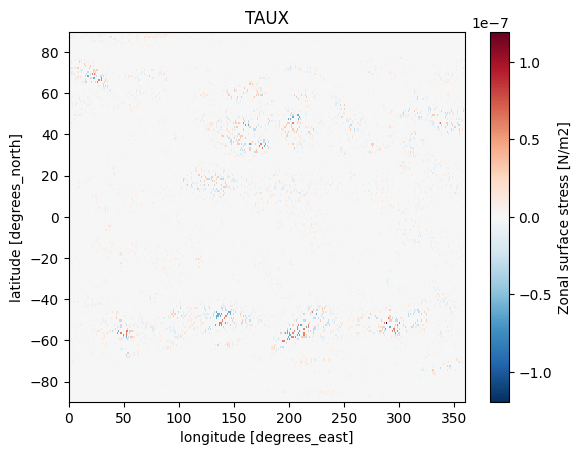

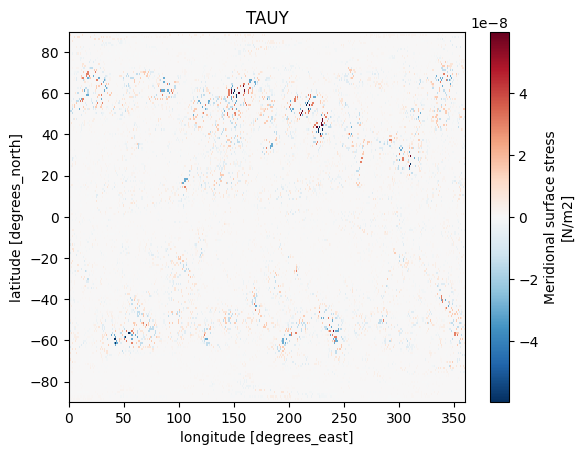

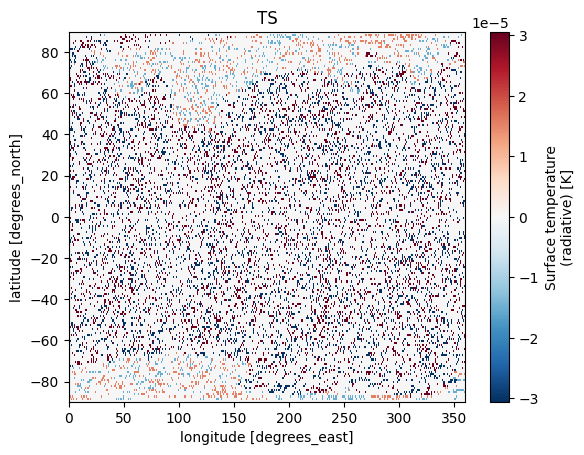

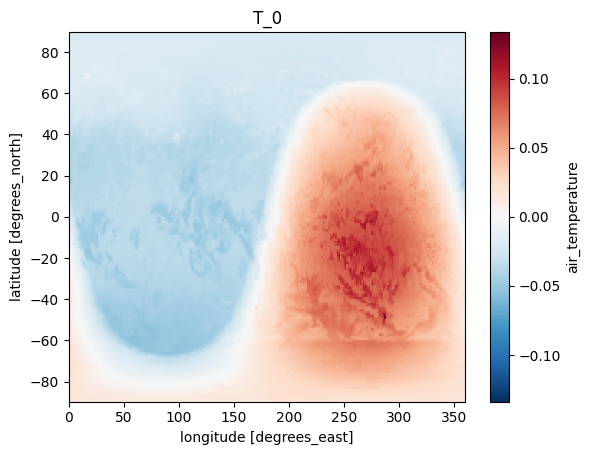

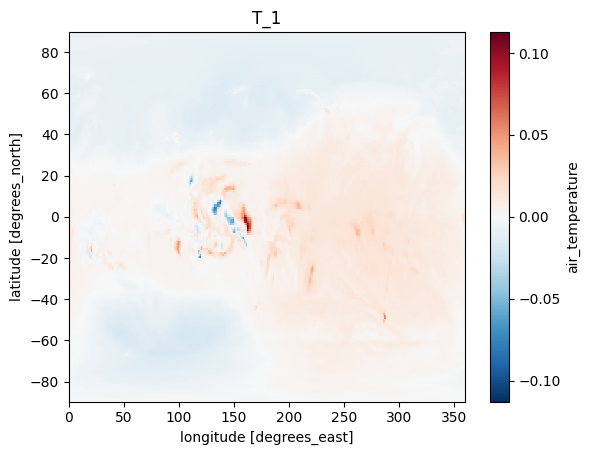

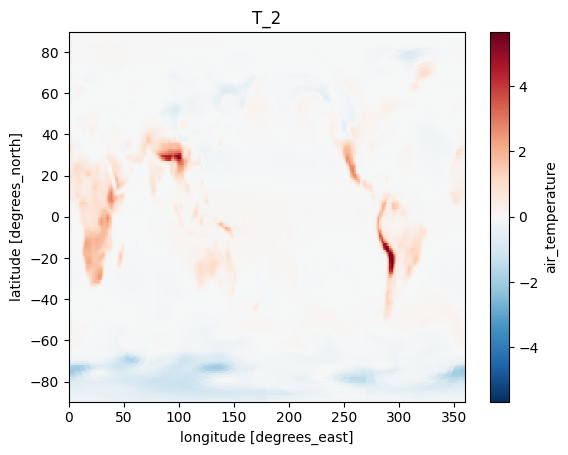

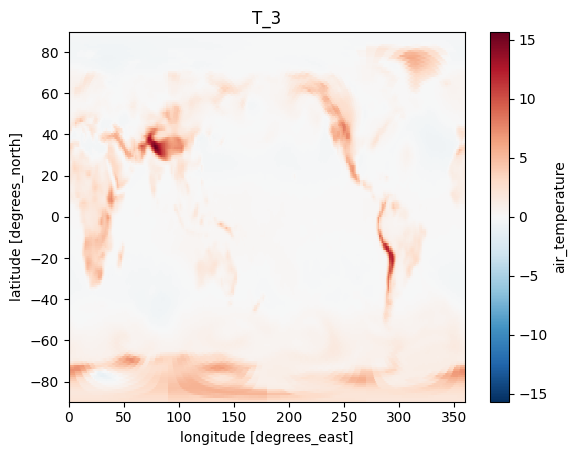

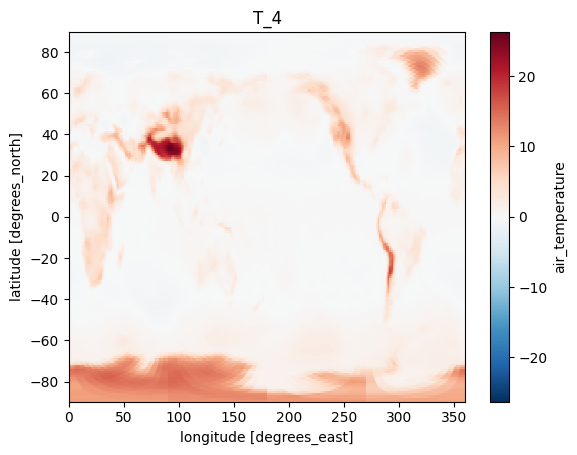

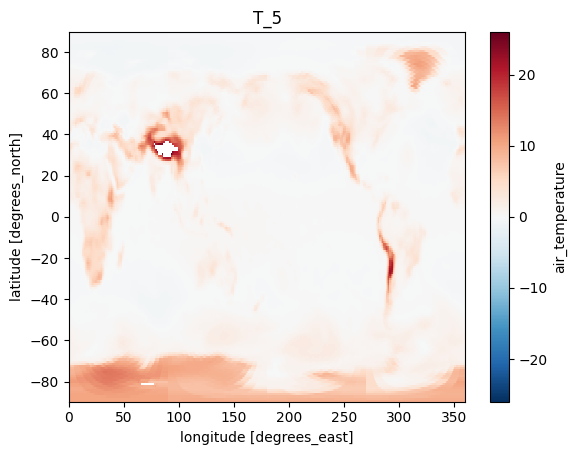

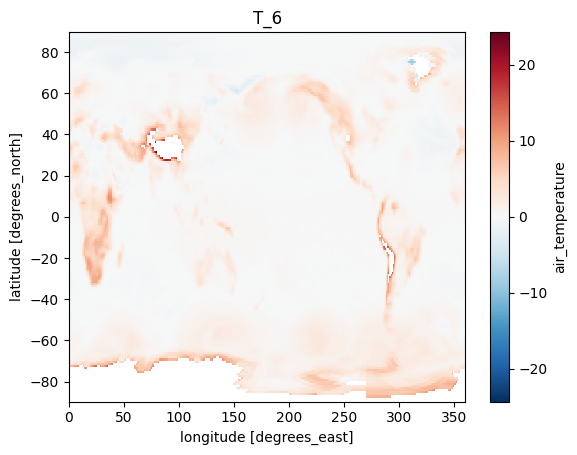

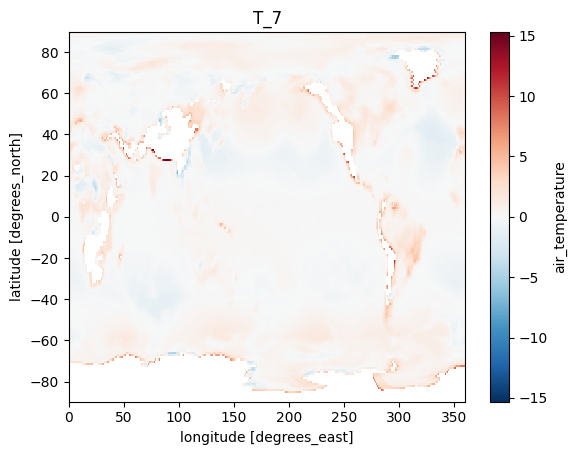

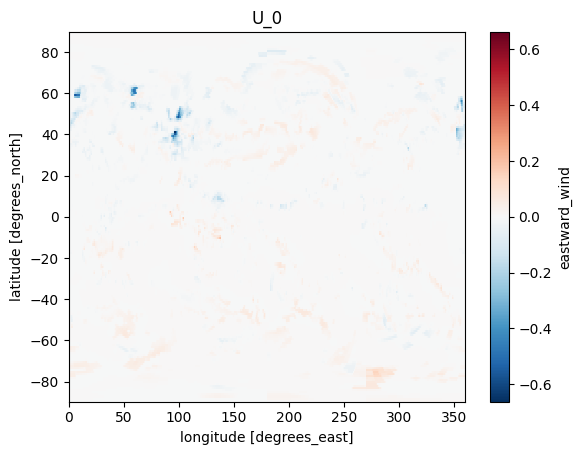

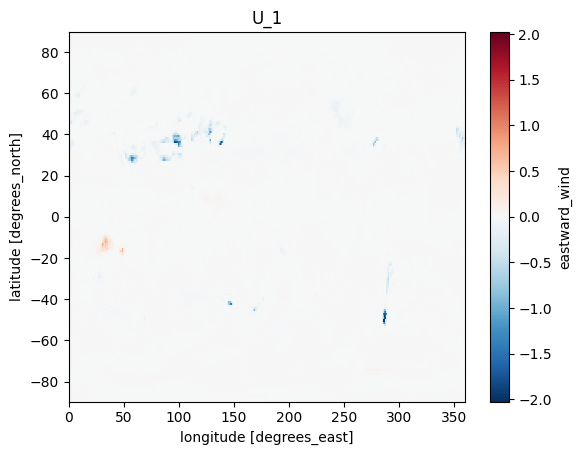

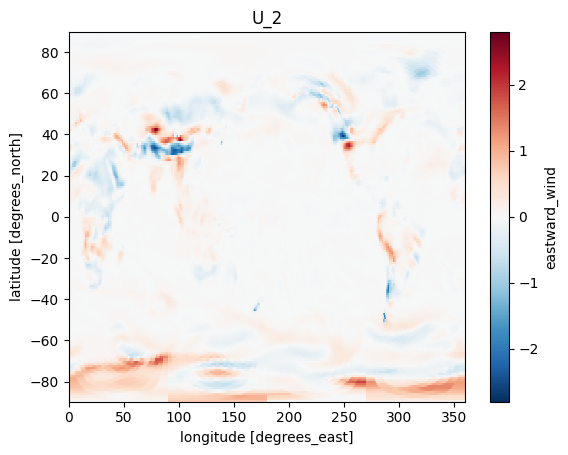

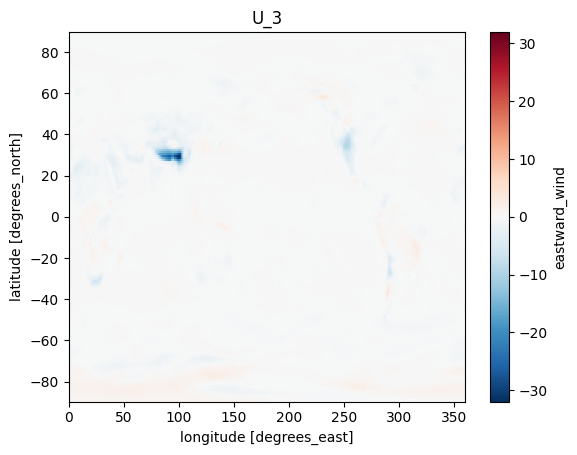

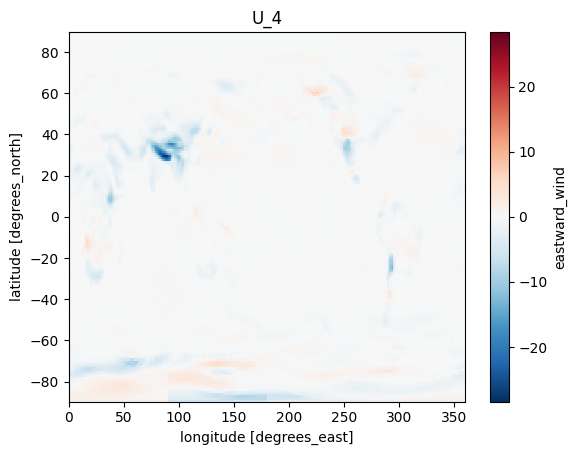

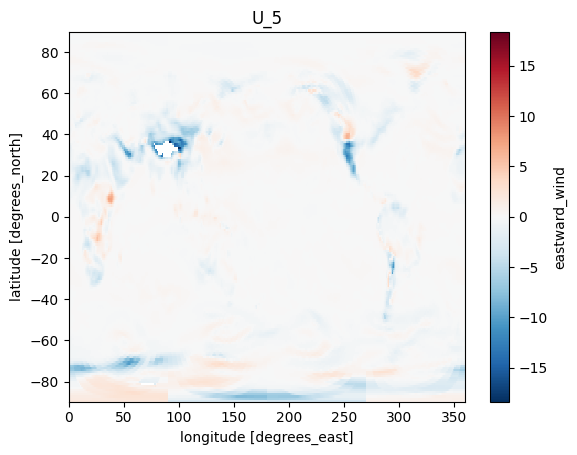

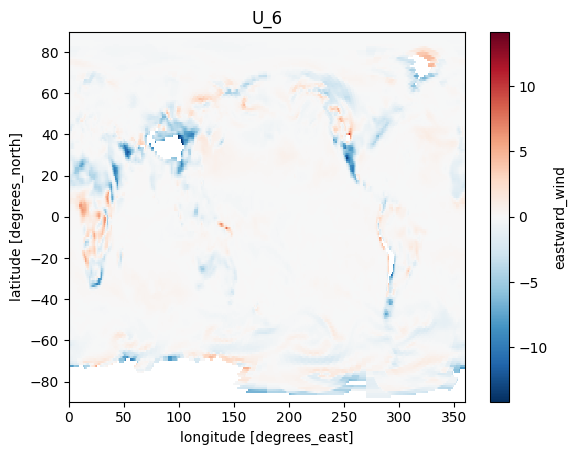

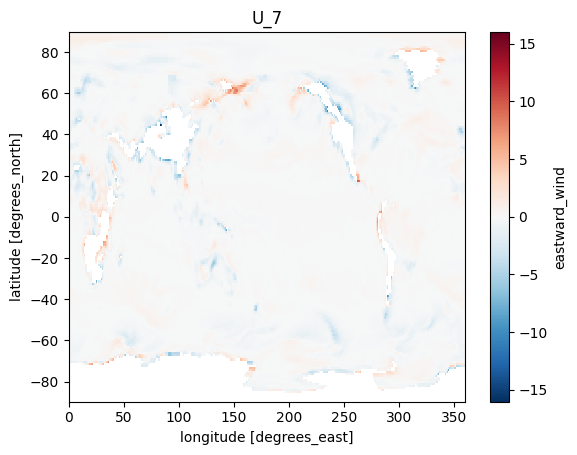

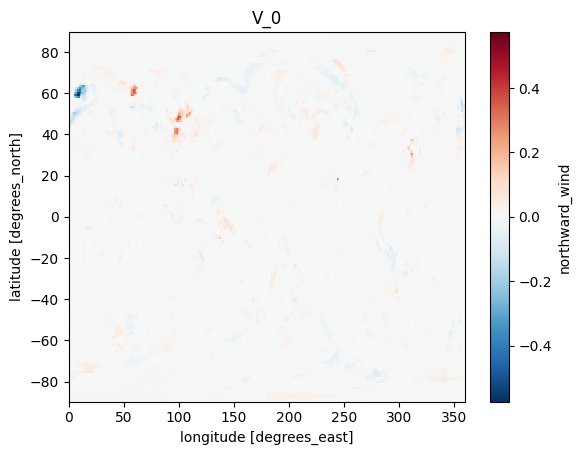

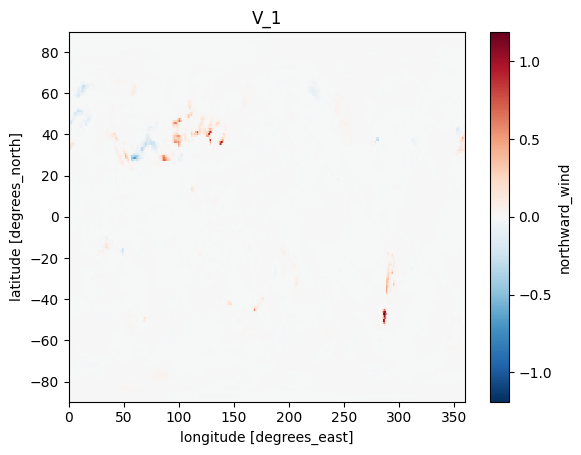

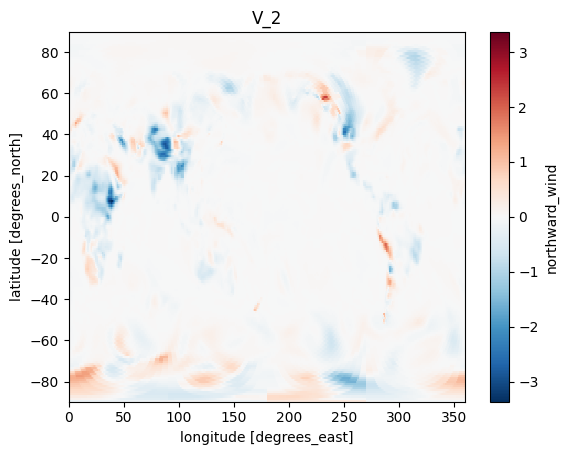

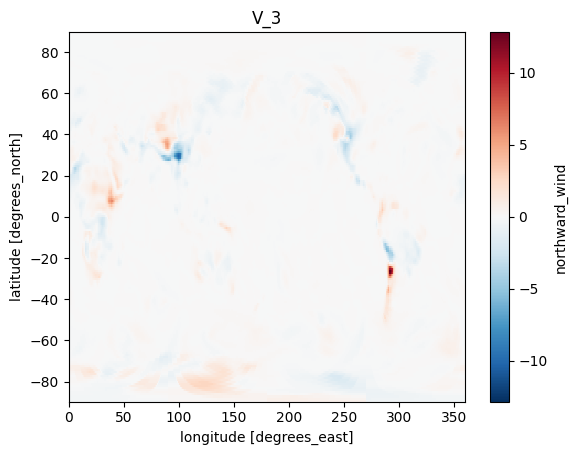

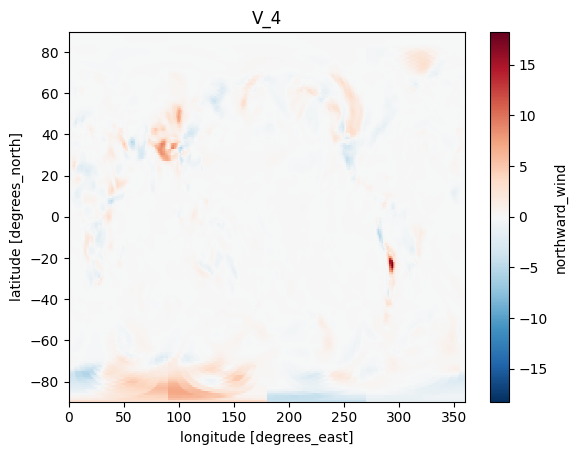

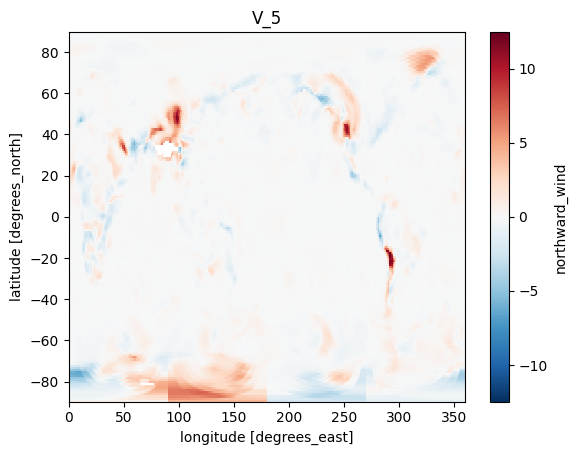

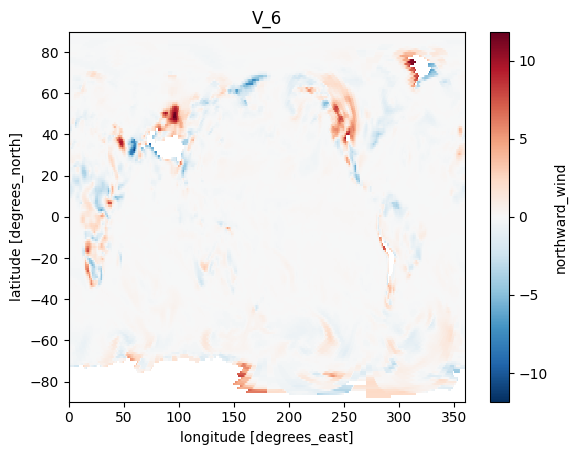

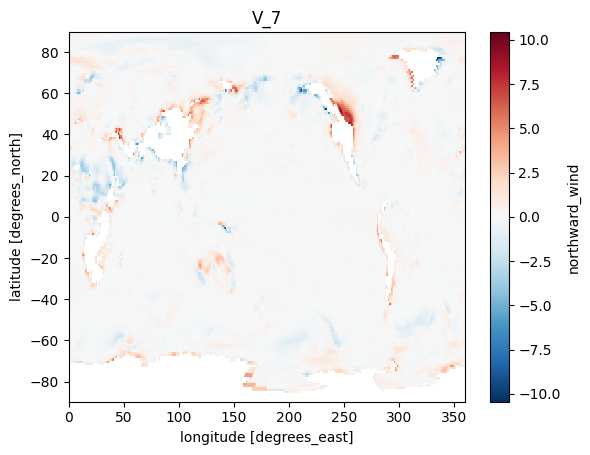

In [22]:
for var in diff.keys():
    if diff[var].dims == ("time", "lat", "lon"):
        plt.figure()
        diff[var].isel(time=-1).plot()
        plt.title(var)